In [1]:
import sys
sys.path.insert(0, "/Users/matt.holden/Projects/tennis-origination")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from injestion.core.bq import get_client
from injestion.sportradar import SportradarManager
from injestion.oddsjam import OddsJamManager
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
from injestion.core.env import load_env
load_env()

import os
os.environ["GOOGLE_CLOUD_PROJECT"] = "prizepicksanalytics"
# If needed, also set your service-account key path:
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/absolute/path/to/key.json"

from google.cloud import bigquery
bq_client = bigquery.Client(project=os.environ["GOOGLE_CLOUD_PROJECT"])

In [4]:
bq_client = get_client()
sr_manager = SportradarManager()
oj_manager = OddsJamManager()

________
### Retrieve Data

In [5]:
def get_pbp_data() -> pd.DataFrame:
    event_timeline_table_id = sr_manager.get_table_id("event_timeline")
    query = f"""
    SELECT * FROM `{event_timeline_table_id}`
    """
    return bq_client.query(query).to_dataframe()

pbp = get_pbp_data()
pbp = pbp[~pbp.timeline_not_available]

In [6]:
def get_event_summary_data() -> pd.DataFrame:
    event_summary_table_id = sr_manager.get_table_id("event_summary")
    query = f"""
    SELECT * FROM `{event_summary_table_id}`
    """
    return bq_client.query(query).to_dataframe()

event_summary = get_event_summary_data()

event_summary["total_sets"] = event_summary["home_score"] + event_summary["away_score"]

In [7]:
def get_event_statistics_data() -> pd.DataFrame:
    event_statistics_table_id = sr_manager.get_table_id("event_statistics")
    query = f"""
    SELECT * FROM `{event_statistics_table_id}`
    """
    return bq_client.query(query).to_dataframe()

event_statistics = get_event_statistics_data()

_________

Merge with event_summary to get player names into play by play

In [8]:
pbp_with_server = pbp.merge(
    event_summary[["sport_event_id", "total_sets", "mode_best_of", "home_competitor_id", "away_competitor_id", "home_competitor_name", "away_competitor_name", "match_status"]], on="sport_event_id", how="left"
)

# server competitor name
pbp_with_server["server_competitor_name"] = np.where(
    pbp_with_server["server"] == "home",  # use your actual column name
    pbp_with_server["home_competitor_name"],
    np.where(
        pbp_with_server["server"] == "away",
        pbp_with_server["away_competitor_name"],
        None,
    ),
)

# server competitor id
pbp_with_server["server_competitor_id"] = np.where(
    pbp_with_server["server"] == "home",
    pbp_with_server["home_competitor_id"],
    np.where(
        pbp_with_server["server"] == "away",
        pbp_with_server["away_competitor_id"],
        None,
    ),
)



Assign set numbers (period) and also remove incomplete/compromised data

In [9]:
def assign_set_from_period_starts(match_timeline: pd.DataFrame) -> pd.Series:
    """Assign set number (period) to each event. One match's rows only."""
    df = match_timeline.sort_values("event_order")
    current_period = None
    started = False
    ended = False
    suspended = False
    periods = []
    for _, row in df.iterrows():
        if row["type"] == "match_started":
            started = True
            periods.append(None)
        elif row["type"] == "match_ended":
            periods.append(None)
            ended = True
        elif not started or ended:
            periods.append(None)
        elif row["type"] == "match_suspended":
            suspended = True
            periods.append(current_period if current_period is None else int(current_period))
        elif suspended and row["type"] == "period_start":
            suspended = False
            periods.append(current_period if current_period is None else int(current_period))
        elif row["type"] == "period_start":
            current_period = (current_period + 1) if current_period is not None else 1
            periods.append(current_period)
        else:
            periods.append(current_period if current_period is None else int(current_period))
    return pd.Series(periods, index=df.index)

def assign_set_from_period_scores(match_timeline: pd.DataFrame) -> pd.Series:
    """
    Infer set number from period_score events only. Use when period_start is missing.
    Only events between match_started and match_ended (inclusive) get a period;
    events before match_started or after match_ended get None.
    A period_score row is the last point of the set; the next row starts the new set.
    """
    df = match_timeline.sort_values("event_order")
    current_period = None
    started = False
    ended = False
    periods = []
    for _, row in df.iterrows():
        if row["type"] == "match_started":
            started = True
            current_period = 1
            periods.append(None)
        elif row["type"] == "match_ended":
            periods.append(None)
            ended = True
        elif not started or ended:
            periods.append(None)
        else:
            periods.append(int(current_period))
            if row["type"] == "period_score":
                h, a = row.get("home_score"), row.get("away_score")
                if pd.notna(h) and pd.notna(a):
                    if max(h, a) == 7 or (max(h, a) == 6 and abs(h - a) >= 2):
                        current_period += 1
    return pd.Series(periods, index=df.index)

def assign_set_null(match_timeline: pd.DataFrame) -> pd.Series:
    return pd.Series(None, index=match_timeline.index)

def assign_set(match_timeline: pd.DataFrame, total_sets: int | None) -> pd.Series:
    if pd.isna(total_sets):
        period_series = assign_set_null(match_timeline)
    else:
        period_series = assign_set_from_period_starts(match_timeline)
        sport_event_id = match_timeline["sport_event_id"].iloc[0]
        if total_sets is not None:
            max_period = period_series.max()
            if pd.isna(max_period) or max_period != total_sets:
                period_series = assign_set_from_period_scores(match_timeline)
                max_period = period_series.max()
                if pd.isna(max_period) or max_period != total_sets:
                    print(f"Failed to assign set for sport_event_id: {sport_event_id}, max_period: {max_period}, total_sets: {total_sets}")
                    period_series = assign_set_null(match_timeline)
    return period_series


In [10]:
pbp_with_server_sorted = pbp_with_server.sort_values(["sport_event_id", "event_order"])

pbp_with_server_sorted_with_period = pbp_with_server_sorted[pbp_with_server_sorted["match_status"] != "retired"]

# building period column by sport_event_id
parts = []
for sid, grp in pbp_with_server_sorted_with_period.groupby("sport_event_id", sort=False):
    total_sets = grp["total_sets"].iloc[0] if "total_sets" in grp.columns else None
    total_sets = int(total_sets) if pd.notna(total_sets) else None
    parts.append(assign_set(grp, total_sets=total_sets))
period_series = pd.concat(parts)
pbp_with_server_sorted_with_period["period"] = period_series

# remove rows where period is not assigned
pbp_with_server_sorted_with_period = pbp_with_server_sorted_with_period[
    pbp_with_server_sorted_with_period.groupby("sport_event_id")["period"].transform(lambda s: s.notna().any())
]

Failed to assign set for sport_event_id: sr:sport_event:58856555, max_period: 1.0, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59152417, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:59276549, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59410453, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:59521813, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59816634, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:61073927, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:61213687, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:62476956, max_period: 3.0, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:62477534, max_period: 4.0, total_sets: 3
Failed to assign set for sport

/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_18189/4080144520.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pbp_with_server_sorted_with_period["period"] = period_series


_______

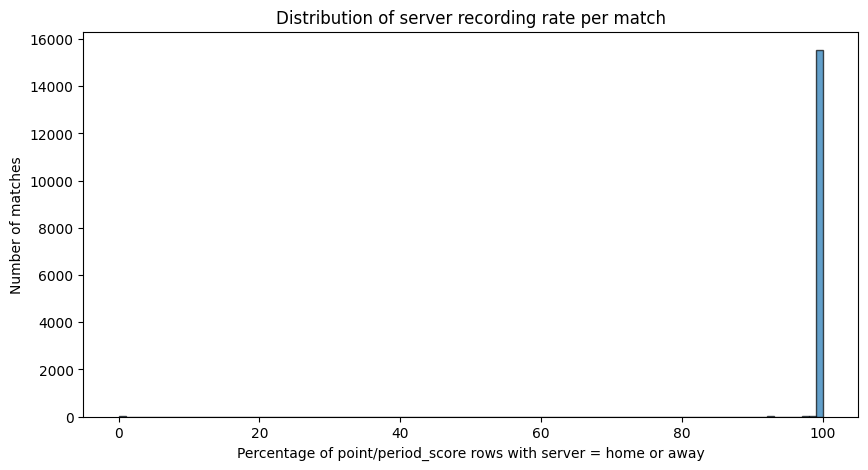

In [11]:
# Restrict to rows where we expect server to be recorded
pbp_points = pbp_with_server_sorted_with_period[
    pbp_with_server_sorted_with_period["type"].isin(["point", "period_score"])
]

# Per-match: % of those rows where server is "home" or "away"
pct_per_match = (
    pbp_points
    .groupby("sport_event_id", sort=False)
    .apply(
        lambda g: (g["server"].isin(["home", "away"]).sum() / len(g) * 100) if len(g) else np.nan,
        include_groups=False,
    )
)
pct_per_match = pct_per_match.dropna()

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(pct_per_match, bins=100, edgecolor="black", alpha=0.7)
plt.xlabel("Percentage of point/period_score rows with server = home or away")
plt.ylabel("Number of matches")
plt.title("Distribution of server recording rate per match")
plt.show()

In [12]:
# Match IDs where 100% of point/period_score rows have server = home or away
match_ids_full_server = pct_per_match[pct_per_match == 100].index

# Restrict dataframe to those matches
pbp_with_server_sorted_with_period = pbp_with_server_sorted_with_period[
    pbp_with_server_sorted_with_period["sport_event_id"].isin(match_ids_full_server)
]

______

Calculate 1st serve percentage for each competitor/match combo

In [13]:
sample_match = pbp_with_server_sorted_with_period[pbp_with_server_sorted_with_period['sport_event_id'] == 'sr:sport_event:64433631'].sort_values(by='event_order')

In [14]:
def get_serve_stats(sample_match, max_sets: int = 5):

    # Competitor ids and match-level metadata from first row
    home_id = sample_match["home_competitor_id"].iloc[0]
    away_id = sample_match["away_competitor_id"].iloc[0]
    mode_best_of = sample_match["mode_best_of"].iloc[0] if "mode_best_of" in sample_match.columns else None
    total_sets = sample_match["total_sets"].iloc[0] if "total_sets" in sample_match.columns else None

    sets_played = int(total_sets) if pd.notna(total_sets) else None
    if sets_played is None:
        period_non_null = sample_match["period"].dropna()
        if len(period_non_null):
            sets_played = int(period_non_null.astype(int).max())

    # Masks: valid server, first serve in (not explicitly a fault)
    valid = sample_match["server"].notna()
    ff = sample_match["first_serve_fault"]
    first_serve_in_mask = (ff != True) | ff.isna()

    # Second serve: attempt = first serve fault; in = not a double fault
    first_serve_fault_mask = ff == True
    second_serve_in_mask = sample_match["result"] != "double_fault"

    home_mask = (sample_match["server"] == "home") & valid
    away_mask = (sample_match["server"] == "away") & valid

    # Double Fault anomaly
    double_fault_mask = sample_match["result"] == "double_fault"
    inconsistent_serve_fault_mask = double_fault_mask & first_serve_in_mask
    if inconsistent_serve_fault_mask.any():
        return None, None

    # ---- Match-level ace counts (denominator for set shares) ----
    aces = sample_match[sample_match["result"] == "ace"]
    home_aces = aces[aces["server"] == "home"]
    away_aces = aces[aces["server"] == "away"]

    home_ace_counts_by_set = home_aces["period"].dropna().astype(int).value_counts().to_dict()
    away_ace_counts_by_set = away_aces["period"].dropna().astype(int).value_counts().to_dict()

    ace_counts_by_competitor = {
        home_id: home_ace_counts_by_set,
        away_id: away_ace_counts_by_set,
    }
    total_aces_by_competitor = {
        home_id: int(len(home_aces)),
        away_id: int(len(away_aces)),
    }

    def pct(attempts, in_count):
        return in_count / attempts if attempts else None

    def set_share_for_competitor(competitor_id: str, set_idx: int):
        if sets_played is not None and set_idx > sets_played:
            return None
        total_aces_for_comp = total_aces_by_competitor[competitor_id]
        set_aces = int(ace_counts_by_competitor[competitor_id].get(set_idx, 0))
        if total_aces_for_comp == 0:
            return 0.0
        return set_aces / total_aces_for_comp

    # ---- Match level: first/second serve ----
    match_first_attempts = {home_id: home_mask.sum(), away_id: away_mask.sum()}
    match_first_in = {
        home_id: (home_mask & first_serve_in_mask).sum(),
        away_id: (away_mask & first_serve_in_mask).sum(),
    }

    match_second_attempts = {
        home_id: (home_mask & first_serve_fault_mask).sum(),
        away_id: (away_mask & first_serve_fault_mask).sum(),
    }
    match_second_in = {
        home_id: ((home_mask & first_serve_fault_mask) & second_serve_in_mask).sum(),
        away_id: ((away_mask & first_serve_fault_mask) & second_serve_in_mask).sum(),
    }

    server_percentage_by_match = {
        home_id: {
            "mode_best_of": int(mode_best_of) if pd.notna(mode_best_of) else None,
            "total_sets": int(sets_played) if sets_played is not None else None,
            "total_aces": total_aces_by_competitor[home_id],
            "first_set_ace_share": set_share_for_competitor(home_id, 1),
            "second_set_ace_share": set_share_for_competitor(home_id, 2),
            "first_serve_attempts": int(match_first_attempts[home_id]),
            "first_serve_in": int(match_first_in[home_id]),
            "first_serve_percentage": pct(match_first_attempts[home_id], match_first_in[home_id]),
            "second_serve_attempts": int(match_second_attempts[home_id]),
            "second_serve_in": int(match_second_in[home_id]),
            "second_serve_percentage": pct(match_second_attempts[home_id], match_second_in[home_id]),
        },
        away_id: {
            "mode_best_of": int(mode_best_of) if pd.notna(mode_best_of) else None,
            "total_sets": int(sets_played) if sets_played is not None else None,
            "total_aces": total_aces_by_competitor[away_id],
            "first_set_ace_share": set_share_for_competitor(away_id, 1),
            "second_set_ace_share": set_share_for_competitor(away_id, 2),
            "first_serve_attempts": int(match_first_attempts[away_id]),
            "first_serve_in": int(match_first_in[away_id]),
            "first_serve_percentage": pct(match_first_attempts[away_id], match_first_in[away_id]),
            "second_serve_attempts": int(match_second_attempts[away_id]),
            "second_serve_in": int(match_second_in[away_id]),
            "second_serve_percentage": pct(match_second_attempts[away_id], match_second_in[away_id]),
        },
    }

    # ---- Set level (only rows with valid numeric period) ----
    df_valid = sample_match.loc[valid & sample_match["period"].notna()].copy()

    def set_level_stats(server_val: str, competitor_id: str):
        sub = df_valid[df_valid["server"] == server_val].copy()
        if sub.empty:
            grouped = pd.DataFrame(columns=[
                "first_serve_attempts",
                "first_serve_in",
                "second_serve_attempts",
                "second_serve_in",
            ])
        else:
            sub["period"] = sub["period"].astype(int)
            grouped = (
                sub.groupby("period", sort=True)
                .apply(
                    lambda g: pd.Series({
                        "first_serve_attempts": len(g),
                        "first_serve_in": ((g["first_serve_fault"] != True) | g["first_serve_fault"].isna()).sum(),
                        "second_serve_attempts": (g["first_serve_fault"] == True).sum(),
                        "second_serve_in": ((g["first_serve_fault"] == True) & (g["result"] != "double_fault")).sum(),
                    }),
                    include_groups=False,
                )
            )

        # Build rows for every played set so played-with-zero-aces stays 0, not null.
        set_stats = {}
        if sets_played is None:
            played_sets = sorted(grouped.index.tolist())
        else:
            played_sets = list(range(1, min(max_sets, sets_played) + 1))

        for period_idx in played_sets:
            if period_idx in grouped.index:
                row = grouped.loc[period_idx]
                first_attempts = int(row["first_serve_attempts"])
                first_in = int(row["first_serve_in"])
                second_attempts = int(row["second_serve_attempts"])
                second_in = int(row["second_serve_in"])
            else:
                first_attempts = 0
                first_in = 0
                second_attempts = 0
                second_in = 0

            set_aces = int(ace_counts_by_competitor[competitor_id].get(period_idx, 0))
            total_aces_for_comp = total_aces_by_competitor[competitor_id]
            set_ace_share = 0.0 if total_aces_for_comp == 0 else (set_aces / total_aces_for_comp)

            set_stats[period_idx] = {
                "first_serve_attempts": first_attempts,
                "first_serve_in": first_in,
                "first_serve_percentage": pct(first_attempts, first_in),
                "second_serve_attempts": second_attempts,
                "second_serve_in": second_in,
                "second_serve_percentage": pct(second_attempts, second_in),
                "ace_count": set_aces,
                "ace_share": set_ace_share,
            }

        return set_stats

    server_percentage_by_set = {
        home_id: set_level_stats("home", home_id),
        away_id: set_level_stats("away", away_id),
    }

    return server_percentage_by_match, server_percentage_by_set


In [15]:
def serve_stats_to_row(
    sport_event_id,
    server_percentage: dict,
    server_percentage_by_set: dict,
    max_sets: int = 5,
) -> pd.DataFrame:
    """
    Flatten match-level and set-level serve stats to one row per competitor.
    Unique key: (sport_event_id, competitor_id). Set columns 1..max_sets; missing sets are null.
    """
    match_cols = [
        "mode_best_of",
        "total_sets",
        "total_aces",
        "first_set_ace_share",
        "second_set_ace_share",
        "first_serve_attempts",
        "first_serve_in",
        "first_serve_percentage",
        "second_serve_attempts",
        "second_serve_in",
        "second_serve_percentage",
    ]
    set_cols = [
        "first_serve_attempts",
        "first_serve_in",
        "first_serve_percentage",
        "second_serve_attempts",
        "second_serve_in",
        "second_serve_percentage",
        "ace_count",
        "ace_share",
    ]
    rows = []
    for competitor_id, match_stats in server_percentage.items():
        row = {
            "sport_event_id": sport_event_id,
            "competitor_id": competitor_id,
        }
        for c in match_cols:
            row[c] = match_stats.get(c)
        set_stats = server_percentage_by_set.get(competitor_id) or {}
        for s in range(1, max_sets + 1):
            st = set_stats.get(s)
            for c in set_cols:
                key = f"set_{s}_{c}"
                row[key] = st.get(c) if st else None
        rows.append(row)
    return pd.DataFrame(rows)


# Build tabular form for this match (sport_event_id from sample_match)
sport_event_id = sample_match["sport_event_id"].iloc[0]
server_percentage_by_match, server_percentage_by_set = get_serve_stats(sample_match)
serve_stats_table = serve_stats_to_row(
    sport_event_id,
    server_percentage_by_match,
    server_percentage_by_set,
    max_sets=5,
)
serve_stats_table

,sport_event_id,competitor_id,mode_best_of,total_sets,total_aces,first_set_ace_share,second_set_ace_share,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_1_ace_count,set_1_ace_share,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_2_ace_count,set_2_ace_share,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_3_ace_count,set_3_ace_share,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_4_ace_count,set_4_ace_share,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage,set_5_ace_count,set_5_ace_share
0,sr:sport_event:64433631,sr:competitor:788260,3,3,2,0.5,0.5,61,38,0.622951,23,20,0.869565,25,18,0.720000,7,6,0.857143,1,0.5,28,18,0.642857,10,9,0.9,1,0.5,8,2,0.25,6,5,0.833333,0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,sr:sport_event:64433631,sr:competitor:1186389,3,3,1,0.0,1.0,54,36,0.666667,18,17,0.944444,28,15,0.535714,13,13,1.000000,0,0.0,17,12,0.705882,5,4,0.8,1,1.0,9,9,1.00,0,0,NaN,0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [16]:
# Example when you have a list of matches / (server_percentage, server_percentage_by_set) per match
def process_match(g):
    """Process one match group: compute serve stats and return tabular rows (one per competitor)."""
    sid = g.name  # group key = sport_event_id
    server_percentage_by_match, server_percentage_by_set = get_serve_stats(g)
    if server_percentage_by_match is None:
        return pd.DataFrame()
    return serve_stats_to_row(sid, server_percentage_by_match, server_percentage_by_set)

serve_stats_table = (
    pbp_with_server_sorted_with_period
    .groupby("sport_event_id", sort=False)
    .apply(process_match)
    .reset_index(drop=True)
)

# Keep match metadata columns as nullable integers for schema compatibility.
for int_col in ["mode_best_of", "total_sets"]:
    serve_stats_table[int_col] = pd.to_numeric(serve_stats_table[int_col], errors="coerce").astype("Int64")

/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_18189/2788296728.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  .apply(process_match)
/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_18189/2788296728.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(process_match)


In [17]:
serve_stats_table.sample()

,sport_event_id,competitor_id,mode_best_of,total_sets,total_aces,first_set_ace_share,second_set_ace_share,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_1_ace_count,set_1_ace_share,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_2_ace_count,set_2_ace_share,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_3_ace_count,set_3_ace_share,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_4_ace_count,set_4_ace_share,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage,set_5_ace_count,set_5_ace_share
16952,sr:sport_event:69826916,sr:competitor:399633,3,3,8.0,0.25,0.375,80.0,51.0,0.6375,29.0,26.0,0.896552,25.0,17.0,0.68,8.0,6.0,0.75,2.0,0.25,27.0,20.0,0.740741,7.0,7.0,1.0,3.0,0.375,28.0,14.0,0.5,14.0,13.0,0.928571,3.0,0.375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
serve_stats_table[serve_stats_table['first_serve_attempts'] < 24]

,sport_event_id,competitor_id,mode_best_of,total_sets,total_aces,first_set_ace_share,second_set_ace_share,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_1_ace_count,set_1_ace_share,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_2_ace_count,set_2_ace_share,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_3_ace_count,set_3_ace_share,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_4_ace_count,set_4_ace_share,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage,set_5_ace_count,set_5_ace_share


The minimum first serve attempts in a game is 24, data has been properly cleaned to remove those matches

In [19]:
cleaned_pbp_with_server = pbp_with_server_sorted_with_period[
    pbp_with_server_sorted_with_period['sport_event_id'].isin(serve_stats_table['sport_event_id'])]

In [20]:
print(cleaned_pbp_with_server['sport_event_id'].nunique())
print(serve_stats_table['sport_event_id'].nunique())

12554
12554


In [21]:
serve_stats_table.dtypes

sport_event_id                    object
competitor_id                     object
mode_best_of                       Int64
total_sets                         Int64
total_aces                       float64
first_set_ace_share              float64
second_set_ace_share             float64
first_serve_attempts             float64
first_serve_in                   float64
first_serve_percentage           float64
second_serve_attempts            float64
second_serve_in                  float64
second_serve_percentage          float64
set_1_first_serve_attempts       float64
set_1_first_serve_in             float64
set_1_first_serve_percentage     float64
set_1_second_serve_attempts      float64
set_1_second_serve_in            float64
set_1_second_serve_percentage    float64
set_1_ace_count                  float64
set_1_ace_share                  float64
set_2_first_serve_attempts       float64
set_2_first_serve_in             float64
set_2_first_serve_percentage     float64
set_2_second_ser

In [22]:
cleaned_pbp_with_server.dtypes

sport_event_id                         object
timeline_not_available                boolean
event_id                                Int64
event_order                             Int64
type                                   object
time                      datetime64[us, UTC]
competitor                             object
period_name                            object
period                                float64
home_score                              Int64
away_score                              Int64
server                                 object
result                                 object
first_serve_fault                     boolean
total_sets                              Int64
mode_best_of                            Int64
home_competitor_id                     object
away_competitor_id                     object
home_competitor_name                   object
away_competitor_name                   object
match_status                           object
server_competitor_name            

________

Create tables BQ tables for serve stats and cleaned serve pbp

In [23]:
from injestion.core.bq import get_client
from refined_tables import replace_table, get_table_id
from refined_tables.schema import serve_stats as schema_serve_stats

client = get_client()
replace_table(
    client,
    get_table_id("serve_stats"),
    serve_stats_table,
    schema=schema_serve_stats.get_schema(),
)

/Users/matt.holden/Projects/tennis-origination/.venv/lib/python3.13/site-packages/google/cloud/bigquery/_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


LoadJob<project=prizepicksanalytics, location=US, id=03fb1600-29e0-4f83-97eb-67c366c85820>

In [24]:
from refined_tables.schema import cleaned_pbp_with_server as schema_cleaned_pbp

client = get_client()
replace_table(
    client,
    get_table_id("cleaned_pbp_with_server"),
    cleaned_pbp_with_server,
    schema=schema_cleaned_pbp.get_schema(),
)

/Users/matt.holden/Projects/tennis-origination/.venv/lib/python3.13/site-packages/google/cloud/bigquery/_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


LoadJob<project=prizepicksanalytics, location=US, id=18e25381-646b-4b70-bacd-0c7c79d01160>